# Importando classes

In [1]:
# Torch
import torch
import torchvision.transforms as transforms
import torchvision
import torchvision.datasets as datasets
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import random_split

# Rodando scripts modularizados
%run "../pyScripts/devFunctions.py"

# PIL
from PIL import Image

# Numpy
# import numpy as np

# Matplot
import matplotlib.pyplot as plt

# Definições

In [2]:
batch_size = 128 # Pode ser interessante aumentar para manter a GPU em maior uso
epoch = 8 # <- Quantidade de ciclos de treinamento
data = "/media/kaua-matheus/HD320/Data/Agroscope/Generalista"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
print(f"Dispositivo Usado: {"GPU" if DEVICE.type == "cuda" else "CPU"}")

Dispositivo Usado: GPU


## Transform

In [4]:
# Usamos uma técnica de Resize, aumentando a imagem e então, após aplicarmos as transformações, realizamos um crop
# Essa técnica é interessante para não criar fundos vázios, visando não gerar valores nulos.

transform = transforms.Compose([
    # transforms.Grayscale(1),
    transforms.Resize((150, 150)),
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),
    transforms.CenterCrop((128, 128)),
    transforms.GaussianBlur(5, 0.8),

    # sobel_transform,
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)), # Normalizando imagem para apenas um canal ao invés de 3 -> (0.5, 0.5, 0.5), (0.5, 0.5, 0.5)
])

## Dataset Principal

In [5]:
full_dataset = datasets.ImageFolder(root=data, transform=transform)

train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size

In [6]:
print(f"All Dataset: {len(full_dataset)}")
print(f"Train (80%): {train_size}")
print(f"Test (20%): {test_size}")

All Dataset: 6428
Train (80%): 5142
Test (20%): 1286


In [7]:
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

In [8]:
# Podemos paralelizar usando persistent_workers=True

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, num_workers=4, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, num_workers=4, shuffle=True)

### Mostrando as imagens do trainset

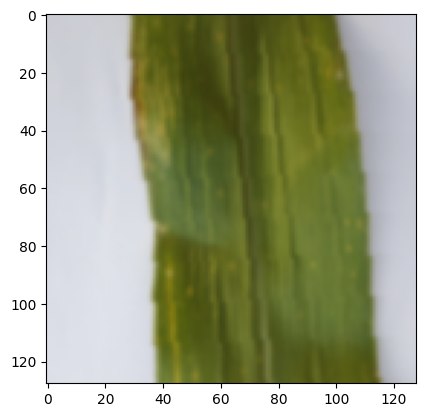

In [9]:
image = Image.open(full_dataset.imgs[4][0])
image_tensor = transform(image)

imshow(torchvision.utils.make_grid(image_tensor.unsqueeze(0)))

# Criando as classes

In [10]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        # Construção das hidden layers
        # Alterado o valor da entrada para 3, visto que agora são 3 canais
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1) # 128
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1) # 64
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3) # 30
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2, 2) # 15
        # self.adaptative_pool = nn.AdaptiveAvgPool2d(7) <- Talvez Aplicar futuramente

        # Flatten
        self.fc1 = nn.Linear(128 * 15 * 15, 120)
        self.bn4 = nn.BatchNorm1d(120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 3)

        # Ativação GeLU
        self.gelu = nn.GELU()
    
    def forward(self, x):
        x = self.pool(F.gelu(self.bn1(self.conv1(x))))
        x = self.pool(F.gelu(self.bn2(self.conv2(x))))
        x = self.pool(F.gelu(self.bn3(self.conv3(x))))

        x = torch.flatten(x, 1)

        x = F.gelu(self.bn4(self.fc1(x)))
        x = F.gelu(self.fc2(x))
        x = self.fc3(x)

        return x


# Definindo o otimizador e a função de perda

In [11]:
Net = NeuralNetwork().to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(Net.parameters(), lr=0.008, momentum=0.9)

# Treinando o modelo

In [12]:
for epoch in range(epoch):

    running_loss = 0.0

    for images, labels in train_loader:

        """
            Nesse caso, images é a representação em matriz da imagem.
            E labels é a representação de cada camada da CNN, se ela ativou ou não.
        """

        # Adquirindo entradas, "data" é uma lista [inputs, labels]
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        # zerando os parâmetros dos gradientes
        optimizer.zero_grad()

        outputs = Net(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        
    print(f'[{epoch + 1}] loss: {running_loss / 2000:.3f}')

print("Treinamento concluído!")

[1] loss: 0.007
[2] loss: 0.002
[3] loss: 0.001
[4] loss: 0.001
[5] loss: 0.001
[6] loss: 0.001
[7] loss: 0.000
[8] loss: 0.001
Treinamento concluído!


# Avaliando o modelo

In [13]:
# Avaliação de resultados
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [27]:
Net.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():  # Desativa o cálculo de gradientes para economizar memória
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = Net(images)

        probabilities = torch.softmax(outputs, dim=1)
        all_probs.extend(probabilities.cpu().numpy())

        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(all_labels, all_preds)
print(f"Accuracy of the model on the test set: {accuracy * 100:.2f}%")

Accuracy of the model on the test set: 99.14%


## Testes Extras

### Confusion Matrix
A matrix de confusão mostra onde o modelo mais se confunde, ou seja, quais classes mais se "parecem" com outras, segundo o modelo.

Na nossa análise, podemos reparar que o modelo mais confunde a ferrugem comum com os outros (saudável e polissora), sendo assim, mais padrões necessitam ser identificados, principalmente na ferrugem comum para melhorar a identificação.\
De todos os erros (27 ao todo), 26 foram na ferrugem comum, confundindo-a com saudável ou polissora.

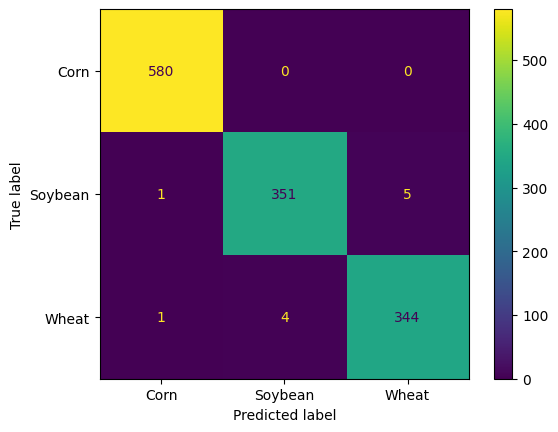

In [28]:
confusion_matrix_eval = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_eval, display_labels=full_dataset.classes)
disp.plot()
plt.show()

### Precision, Recall e F1-Score
Necessário para identificar ponderação nas predições. Em alguns datasets, a quantidade de registros de uma classe pode ser maior do que outras, isso significa um desbalanço nos dados, portanto, uma ponderação de acerto deve ser aplicada.\
Por conta disso, F1-Score avalia a média harmônica da precisão e do recall, visando encontrar um indicador de bom equilibrio entre corretamente positivos e todos os positivos.\
O valor de F1 varia de 0 e 1, onde 1 é o melhor.

In [29]:
f1 = f1_score(all_labels, all_preds, average=None)
f1

array([0.99827883, 0.98595506, 0.98567335])

### Roc e Auc

In [30]:
import numpy as np
all_probs = np.array(all_probs)

In [31]:
roc_auc = roc_auc_score(all_labels, all_probs, multi_class="ovo")
print(f"Roc-Auc Score: {roc_auc:.4f}")

Roc-Auc Score: 0.9992


In [32]:
roc_auc_macro = roc_auc_score(all_labels, all_probs, multi_class="ovr")
print(f"Roc-Auc Macro: {roc_auc_macro:.4f}")

Roc-Auc Macro: 0.9993


# Salvando Modelo

In [33]:
torch.save(Net.state_dict(), "./Models/New Models/generalAI_v1.pth")

# Carregando Modelo

In [ ]:
model = torch.load("./Models/New Models/generalAI_v1.pth")